# 17 — Preliminary check: richer store data → better beliefs → more profit?

## What this notebook does

This is a **scaled rehearsal** before larger cloud batch runs. It asks two
linked questions in parallel:

1. **Beliefs:** If the true shelf state is held fixed, does giving the filter
   **more store data** produce estimates that are closer to reality? (We score
   count and freshness error, not dollars.)
2. **Profit:** Under the same simulated week, does ordering with those data
   packages change **total profit** when the controller uses a simple
   base-stock policy (no forward simulation)?

Budget: **8 gsin shards** (4 shelf regimes × 2 random seeds), then **28 profit
jobs** (6 data packages × 4 seeds, plus 4 oracle ceiling rows). Scored window is
two warm-up days and **14 scored days** — enough to see patterns, not to publish
final value-of-information numbers.

Set `SMOKE=True` in the config cell to shrink grids for a quick plumbing check
(one gsin shard, one seed, two scored days).

## Background: adding data step by step

Each row below is a **data package** — a bundle of fields the store might actually
have in its systems. We compare six packages in the profit section, plus a
hypothetical ceiling:

| Data package | What the store receives | Role in this notebook |
| --- | --- | --- |
| **Books only** | Register totals (sales in/out); no waste logging, no delivery paperwork | Baseline |
| **Books + waste scans** | Books plus scanned waste counts | First operational upgrade |
| **Lot-level sales & waste** | GSIN-level sales and waste events | Lot tracking without delivery detail |
| **Pack date on advance notice** | Waste scans plus pack date on the ASN | Often strong for freshness estimates |
| **Lot detail + pack date** | Full lot tracking with pack date on ASN | Richer lot + delivery fields |
| **Temperature trace** | Lot-level detail plus cold-chain temperature history | Richest trace tested here |
| **Perfect information** | Hypothetical ceiling: `EngineSession` with `belief_source=truth` (policy sees ground truth, filter off) | Same physics/calendar/policy as channel rows; benchmark for belief quality |

**Part 1 (filter accuracy):** a diagnostic tool replays the **same ground-truth
week** under six data packages and reports average error, aggregated across seeds
within each shelf regime.

**Part 2 (profit):** the simulator runs a scored week per package with
base-stock ordering only (no Monte Carlo rollout) and a pre-tuned smoothing
parameter from `experiments/tuned_alpha.json`.

## How to run

From the **repo root** (not `notebooks/`):

```bash
uv sync --python 3.11
cargo build -p voi_core --release --example gsin_upc_diag
uv run maturin build --release -m crates/voi_py/Cargo.toml -o dist/wheel
uv run jupyter lab notebooks/
```

- Default: `BATCH_MODE = "modal"` (needs a Modal account and built wheel + diagnostic binary).
- Laptop fallback: `BATCH_MODE = "local"` after `maturin develop`.
- **Restart the kernel** after rebuilding artifacts — Modal caches the image on first import.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import os
from pathlib import Path
from typing import Literal

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
for _candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (_candidate / "src" / "blueberries_voi").is_dir():
        REPO_ROOT = _candidate
        break

_wheel_dir = REPO_ROOT / "dist" / "wheel"
_gsin_bin = REPO_ROOT / "target" / "release" / "examples" / "gsin_upc_diag"
os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
if _wheel_dir.is_dir():
    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)
if _gsin_bin.is_file():
    os.environ["GSIN_UPC_DIAG_BIN"] = str(_gsin_bin)

from blueberries_voi.experiments.gsin_upc import REGIME_TITLES
from blueberries_voi.experiments.modal_dispatch import run_batch
from blueberries_voi.filter.types import channels_cache_key, channels_for_preset

# Plain-language labels for internal scenario codes (charts + tables only).
DATA_PACKAGE_LABELS: dict[str, str] = {
    "P0": "Books only",
    "P1": "Books + waste scans",
    "F1": "Lot-level sales & waste",
    "F2a": "Waste scans + pack date",
    "F2": "Lot detail + pack date",
    "F3": "Temperature trace",
    "B-state": "Perfect information (ceiling)",
}

BATCH_MODE: Literal["modal", "local"] = "modal"
SMOKE = False  # set True to shrink grids for a quicker plumbing check

FILTER_DIAG_CELLS = [(r, s) for r in range(4) for s in range(2)]  # 8 gsin shards
PROFIT_SEEDS = (42, 7, 101, 2024)
# Internal preset ids → wired through channels_for_preset; labels are for display.
PROFIT_PRESET_IDS = ("P0", "P1", "F1", "F2a", "F2", "F3")
PROFIT_CHANNELS = [channels_for_preset(s) for s in PROFIT_PRESET_IDS]
PROFIT_LABELS = {
    channels_cache_key(ch): DATA_PACKAGE_LABELS[s]
    for s, ch in zip(PROFIT_PRESET_IDS, PROFIT_CHANNELS, strict=True)
}
N_BURN, N_SCORE = 2, 14

## Part 1 — How accurate is the filter? (gsin diagnostic grid)

The filter-accuracy diagnostic keeps the **true shelf fixed** and asks: “If we only
allowed the filter to see data package *X*, how wrong would its beliefs be?” It
replays six packages (books-only through temperature trace) and prints one row per
package.

We launch **eight cloud jobs** — four shelf regimes (`REGIME_TITLES`) × two random
seeds — then aggregate mean error by `(regime, data_package)` before plotting.

**Metrics (lower is better):**
- `count_mae` — error in total on-shelf count belief
- `store_mean_f_mae` — error in mean freshness belief

In [2]:
filter_rows = run_batch(
    "gsin",
    BATCH_MODE,
    smoke=SMOKE,
    gsin_cells=FILTER_DIAG_CELLS,
)
filter_df = pd.DataFrame(filter_rows)
filter_df["data_package"] = filter_df["channel"].map(DATA_PACKAGE_LABELS)
filter_agg = (
    filter_df.groupby(["regime", "data_package"], as_index=False)[["count_mae", "store_mean_f_mae"]]
    .mean()
)
filter_agg

modal batch:   0%|          | 0/8 [00:00<?, ?shard/s]

[2026-08-24T21:19:14Z] modal batch collected 8 shards


,regime,data_package,count_mae,store_mean_f_mae
0,"Heterogeneous fleet, deep shelf",Books + waste scans,6.03920,0.087087
1,"Heterogeneous fleet, deep shelf",Books only,10.54410,0.091969
2,"Heterogeneous fleet, deep shelf",Lot detail + pack date,117.95135,0.080196
3,"Heterogeneous fleet, deep shelf",Lot-level sales & waste,227.62095,0.120680
4,"Heterogeneous fleet, deep shelf",Temperature trace,22.93665,0.025710
5,"Heterogeneous fleet, deep shelf",Waste scans + pack date,2.49765,0.023443
6,"Heterogeneous fleet, overlapping lots",Books + waste scans,5.36430,0.115165
7,"Heterogeneous fleet, overlapping lots",Books only,5.74720,0.117525
8,"Heterogeneous fleet, overlapping lots",Lot detail + pack date,4.16680,0.035298
9,"Heterogeneous fleet, overlapping lots",Lot-level sales & waste,106.83375,0.142987


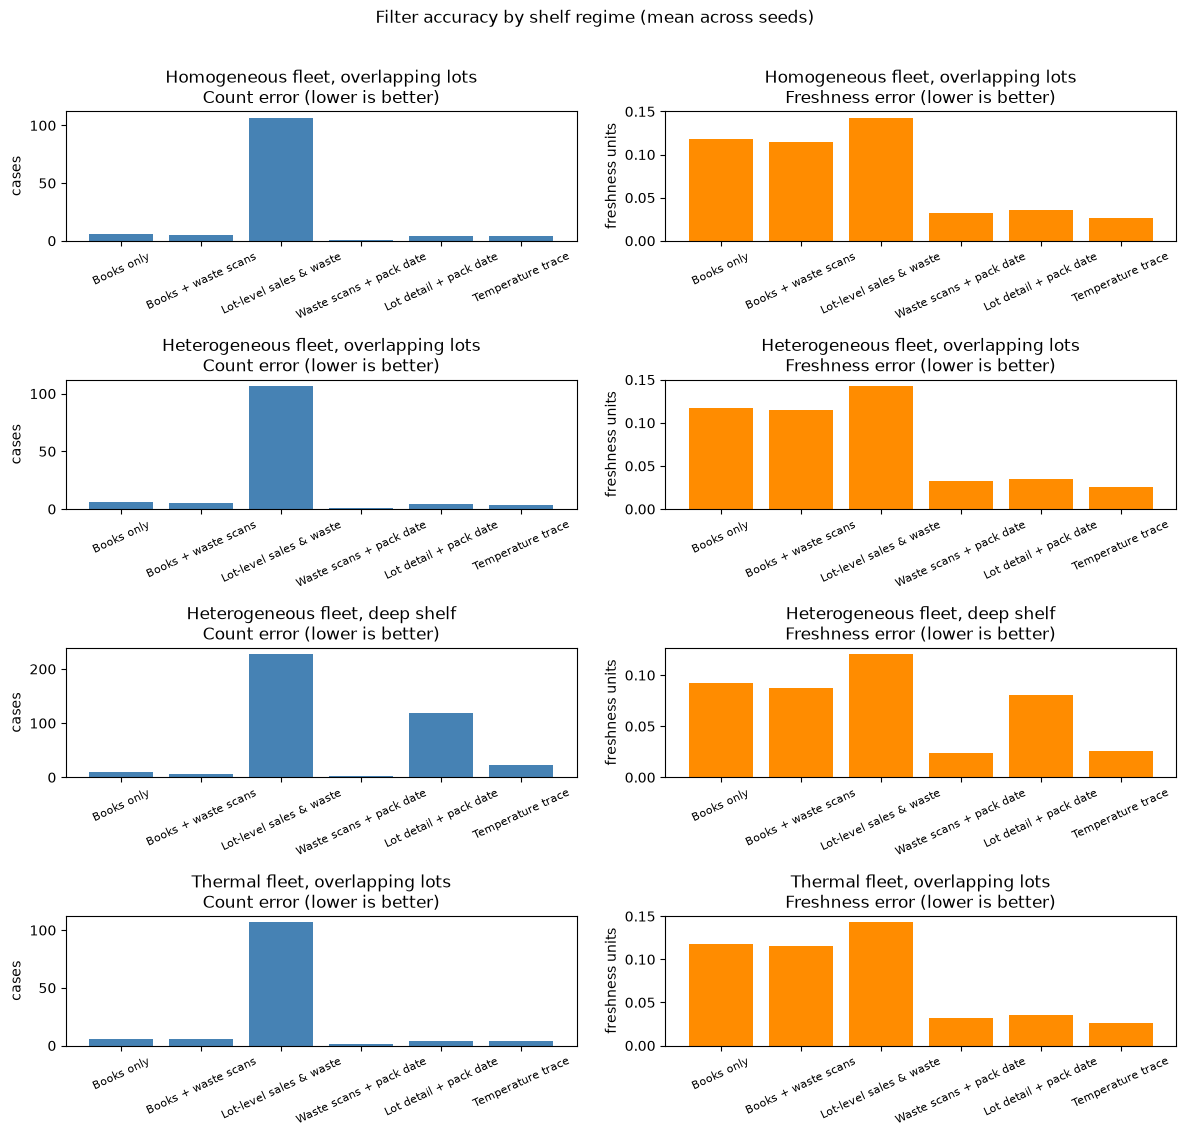

In [3]:
_DISPLAY_ORDER = [
    "Books only",
    "Books + waste scans",
    "Lot-level sales & waste",
    "Waste scans + pack date",
    "Lot detail + pack date",
    "Temperature trace",
]
_regime_order = [r for r in REGIME_TITLES if r in filter_agg["regime"].unique()]
plot_filter = (
    filter_agg.set_index(["regime", "data_package"])
    .reindex(
        pd.MultiIndex.from_product(
            [_regime_order, _DISPLAY_ORDER],
            names=["regime", "data_package"],
        ),
        fill_value=np.nan,
    )
    .reset_index()
)

n_regimes = len(_regime_order)
fig, axes = plt.subplots(n_regimes, 2, figsize=(12, 2.8 * n_regimes), squeeze=False)
for i, regime in enumerate(_regime_order):
    sub = plot_filter[plot_filter["regime"] == regime]
    axes[i, 0].bar(sub["data_package"], sub["count_mae"], color="steelblue")
    axes[i, 0].set_title(f"{regime}\nCount error (lower is better)")
    axes[i, 0].set_ylabel("cases")
    axes[i, 1].bar(sub["data_package"], sub["store_mean_f_mae"], color="darkorange")
    axes[i, 1].set_title(f"{regime}\nFreshness error (lower is better)")
    axes[i, 1].set_ylabel("freshness units")
    for ax in (axes[i, 0], axes[i, 1]):
        ax.tick_params(axis="x", rotation=25, labelsize=8)
fig.suptitle("Filter accuracy by shelf regime (mean across seeds)", y=1.01)
fig.tight_layout()
plt.show()

### Part 1 — What to look for

**Modal run (2026-08-24):** 8 gsin shards, ~48 s wall time. Means below aggregate the two seeds per regime.

| Data package | Mean count error (cases) | Mean freshness error |
| --- | ---: | ---: |
| Temperature trace | 8.6 | **0.026** |
| Waste scans + pack date | 1.3 | 0.030 |
| Lot detail + pack date | 32.6 | 0.047 |
| Books + waste scans | 5.5 | 0.108 |
| Books only | 6.9 | 0.111 |
| Lot-level sales & waste | **137.0** | 0.137 |

**Freshness:** **Waste scans + pack date** wins on the deep-shelf regime (0.023); **Temperature trace** is best on the three overlapping-lot regimes (~0.026). Pack-date and temperature fields clearly beat books-only baselines on freshness.

**Count:** **Lot-level sales & waste** blows up count error (~137 cases MAE averaged across regimes) — the diagnostic struggles without delivery context. **Waste scans + pack date** keeps count error low (~1.3) while also sharpening freshness.

**Regime spread:** Deep-shelf rankings differ from overlapping-lot regimes (e.g. pack-date package is count-best on deep shelf but not on overlapping lots).

**Caveats:** two seeds per regime; diagnostic replay only. Rankings are directional until the full 48-cell grid (notebook 14) is affordable.


## Part 2 — Closed-loop profit (same data packages)

Here the filter **feeds the ordering policy** each day. Budget: two warm-up days,
**14 scored days**, **four random seeds**, and six data packages (plus oracle ceiling).

| Setting | Value | Why |
| --- | --- | --- |
| Policy | Base-stock only (no forward rollout) | Default production policy; isolates data value from simulation cost |
| Order smoothing | From `experiments/tuned_alpha.json` | Pre-tuned on a longer run |
| Seeds | `(42, 7, 101, 2024)` | Same stream per seed across packages |
| Ceiling row | `EngineSession` `belief_source=truth` | Same stack as channel rows; policy reads ground-truth belief |

**What to look for:** profit is **not** guaranteed to track filter error. Better
beliefs can still yield similar orders, or profit can move because of demand and
spoilage while error barely changes — especially over a short scored window.

In [4]:
profit_rows = run_batch(
    "voi_profit",
    BATCH_MODE,
    smoke=SMOKE,
    seeds=PROFIT_SEEDS,
    channels=PROFIT_CHANNELS,
    include_oracle=True,
    n_burn=N_BURN,
    n_score=N_SCORE,
    n_rollout_paths=0,
)
profit_df = pd.DataFrame(profit_rows)
profit_df["data_package"] = (
    profit_df["key"].map(PROFIT_LABELS)
    .fillna(profit_df.get("preset", "").map(DATA_PACKAGE_LABELS))
)
profit_summary = (
    profit_df.groupby("data_package")[["profit", "waste", "stockout"]]
    .mean()
    .sort_values("profit", ascending=False)
)
profit_summary

modal batch:   0%|          | 0/28 [00:00<?, ?shard/s]

[2026-08-24T21:19:33Z] modal batch collected 28 shards


,profit,waste,stockout
data_package,,,
Perfect information (ceiling),437.00,0.0,0.00
Temperature trace,331.50,71.5,40.75
Lot detail + pack date,327.75,69.0,42.25
Waste scans + pack date,327.75,69.0,42.25
Books + waste scans,312.25,68.5,45.50
Books only,312.25,68.5,45.50
Lot-level sales & waste,308.50,68.5,46.25


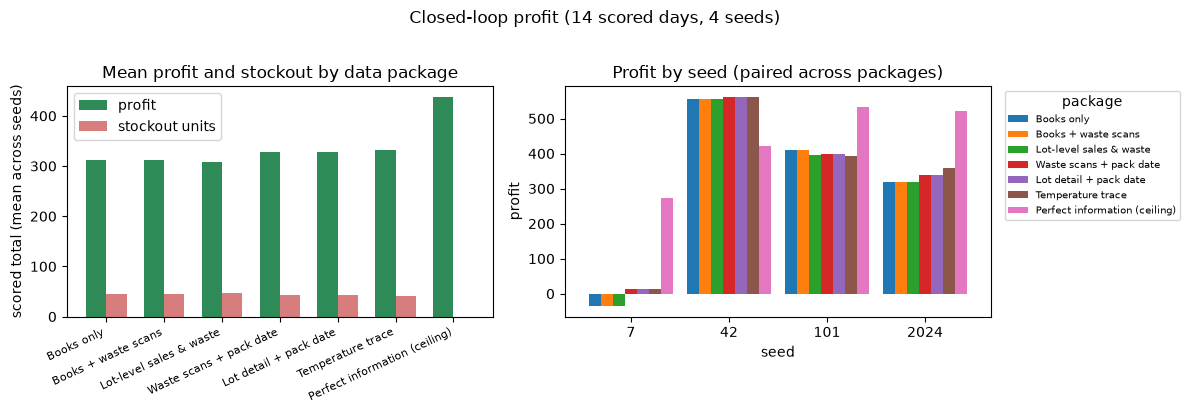

In [5]:
_PROFIT_ORDER = [
    "Books only",
    "Books + waste scans",
    "Lot-level sales & waste",
    "Waste scans + pack date",
    "Lot detail + pack date",
    "Temperature trace",
    "Perfect information (ceiling)",
]
plot_profit = (
    profit_df.groupby("data_package")[["profit", "waste", "stockout"]]
    .mean()
    .reindex([label for label in _PROFIT_ORDER if label in profit_df["data_package"].values])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = range(len(plot_profit))
width = 0.35
axes[0].bar([i - width / 2 for i in x], plot_profit["profit"], width=width, label="profit", color="seagreen")
axes[0].bar([i + width / 2 for i in x], plot_profit["stockout"], width=width, label="stockout units", color="indianred", alpha=0.8)
axes[0].set_xticks(list(x), plot_profit["data_package"], rotation=25, ha="right", fontsize=8)
axes[0].set_ylabel("scored total (mean across seeds)")
axes[0].set_title("Mean profit and stockout by data package")
axes[0].legend()

seed_pivot = profit_df.pivot_table(index="seed", columns="data_package", values="profit", aggfunc="mean")
seed_pivot = seed_pivot.reindex(columns=[c for c in _PROFIT_ORDER if c in seed_pivot.columns])
seed_pivot.plot.bar(ax=axes[1], width=0.85)
axes[1].set_title("Profit by seed (paired across packages)")
axes[1].set_ylabel("profit")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="package", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
fig.suptitle(f"Closed-loop profit ({N_SCORE} scored days, {len(PROFIT_SEEDS)} seeds)", y=1.02)
fig.tight_layout()
plt.show()

### Part 2 — What to look for

**Modal run (2026-08-24):** 28 profit shards (6 packages × 4 seeds + 4 oracle rows), ~19 s wall time. Means over four seeds `(42, 7, 101, 2024)`, 14 scored days, base-stock only. *(Oracle waste/stockout were placeholders before session-aligned truth belief; re-run Part 2 after rebuild for updated ceiling tallies.)*

| Data package | Mean profit | Mean waste | Mean stockout |
| --- | ---: | ---: | ---: |
| Perfect information (ceiling) | **437.0** | *(re-run)* | *(re-run)* |
| Temperature trace | 331.5 | 71.5 | 40.8 |
| Lot detail + pack date | 327.8 | 69.0 | 42.3 |
| Waste scans + pack date | 327.8 | 69.0 | 42.3 |
| Books + waste scans | 312.3 | 68.5 | 45.5 |
| Books only | 312.3 | 68.5 | 45.5 |
| Lot-level sales & waste | 308.5 | 68.5 | 46.3 |

**Ranking:** Among real data feeds, **Temperature trace** leads by ~$4 over the tied pack-date packages; books-only baselines sit ~$15–$23 lower. The oracle ceiling ($437) is ~$106 above the best real package — better beliefs do not automatically mean highest profit here.

**Beliefs ≠ profit:** Part 1 showed catastrophic count error for lot-level sales & waste, yet Part 2 places it only ~$23 below the leader — ordering barely moves. Pack-date and temperature packages that win on freshness do lead profit, but the spread is narrow.

**Caveats:** base-stock only, four seeds, one controller world. Do not treat ~$20 mean-profit gaps as business recommendations without wider seeds and longer horizons.


## How Part 1 and Part 2 fit together

The two parts measure **different things on purpose**:

- **Part 1** freezes reality and scores belief error only (8 gsin shards; means over two seeds per regime).
- **Part 2** lets beliefs drive orders and scores dollars (6 packages + oracle, 4 seeds, 14 scored days).

**This run (2026-08-24):** Part 1 says **temperature trace** and **waste scans + pack date** sharpen freshness beliefs; **lot-level sales & waste** is unusable for count (~137 cases MAE). Part 2 still ranks lot-level only ~$23 below the leader on profit ($308 vs $332) while the oracle ceiling sits ~$106 higher ($437) — belief quality and dollars diverge as expected.

Those answers **diverge by design**. A package that wins on freshness accuracy may not win on profit; lot-level packages may look poor in Part 1 yet sit mid-pack in Part 2.

**Caveats:** two seeds per regime in Part 1, four profit seeds, base-stock controller. See `experiments/modal/PRELIM_SCALING.md` for the next budget tier when Modal ceilings rise beyond ~10 min / 2 CPU-hr per notebook.
